In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import ast
from decimal import Decimal, ROUND_HALF_UP

In [2]:
def assign_range(row, M02, M03):
    filename = row["file_name"]
    profile = row["profile"]
    soc = row["SOC_start"]

    # --- UDDS / NEDC / WLTC ---
    if profile in ["UDDS", "NEDC", "WLTC"]:
        if filename.endswith("_01.csv"):
            return "95-75"
        elif filename.endswith("_02.csv"):
            return "75-55"
        elif filename.endswith("_03.csv"):
            return "55-35"
        else:
            return None

    # --- остальные импульсы ---
    else:
        if soc > M02:
            return "95-75"
        elif soc <= M02 and soc > M03:
            return "75-55"
        else:  # soc <= M03
            return "55-35"


In [3]:
current_dir = Path.cwd()

profiles_description_path = current_dir.parent.parent / "Parameters" / "dynamic_parameters" / "profiles_description_dynamic_parameters.csv"

df = pd.read_csv(profiles_description_path)

In [4]:
df

,bat_num,temp,profile,U_start_V,U_end_V,file_name,Q_Ah,eta,OCV_file_name,SOC_start,SOC_end,SOH,R0,R,tau,U_rmse
0,1,25,impulse_72_s,4.11093,4.10372,1_+25_impulse_72_s_01.csv,3.289069,0.993163,OCV_1_+25.csv,96.579538,95.849146,93.973411,0.046658,"[0.026392653327967048, -0.012839133657306021]","[14.717540211921936, 5.4591520058440715]",0.002368
1,1,25,impulse_144_s,4.10372,4.09365,1_+25_impulse_144_s_02.csv,3.289069,0.993163,OCV_1_+25.csv,95.849146,94.516093,93.973411,0.045836,"[0.02814305030422366, -0.01178216117043148]","[34.48678494176658, 30.05891234073363]",0.000985
2,1,25,impulse_288_s,4.09365,4.07940,1_+25_impulse_288_s_03.csv,3.289069,0.993163,OCV_1_+25.csv,94.516093,91.610379,93.973411,0.044436,"[0.02639665313232317, -0.006190294396990616]","[52.97984432998735, 42.030935197811715]",0.001543
3,1,25,impulse_72_s,4.07940,4.07487,1_+25_impulse_72_s_04.csv,3.289069,0.993163,OCV_1_+25.csv,91.610379,90.357663,93.973411,0.044131,"[0.033353721414509305, -0.01605404005857362]","[17.655506063766932, 4.345021453550078]",0.004843
4,1,25,impulse_144_s,4.07487,4.06139,1_+25_impulse_144_s_05.csv,3.289069,0.993163,OCV_1_+25.csv,90.357663,86.572312,93.973411,0.047324,"[0.47294357380839763, -0.44575254668871717]","[46.9001152179957, 44.839056679051694]",0.005681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
535,5,35,NEDC,3.95779,3.75069,5_+35_NEDC_02.csv,3.434987,0.991690,OCV_5_+35.csv,76.178929,55.833428,98.142481,0.038214,"[2.031496677433247, -1.993452981747819]","[76.84387063474959, 76.31000501854095]",0.003792
536,5,35,NEDC,3.75069,3.59529,5_+35_NEDC_03.csv,3.434987,0.991690,OCV_5_+35.csv,55.833428,36.393882,98.142481,0.035847,"[0.045370198512140955, -0.02172819334654729]","[76.94435608058002, 74.5220880428828]",0.000983
537,5,35,WLTC,4.11297,3.90308,5_+35_WLTC_01.csv,3.434987,0.991690,OCV_5_+35.csv,96.318219,70.142435,98.142481,0.036196,"[-0.004860967333885758, 0.03105412848723179]","[65.88096966579815, 56.60257190958944]",0.005367
538,5,35,WLTC,3.90308,3.68861,5_+35_WLTC_02.csv,3.434987,0.991690,OCV_5_+35.csv,70.142435,49.435377,98.142481,0.038252,"[0.22232121311128444, -0.17921830839497643]","[66.02733769064086, 56.66570054514804]",0.007580


In [5]:
profiles_for_mean = ["UDDS", "NEDC", "WLTC"]
suffixes = ["01", "02", "03"]

df_profiles = df[df["profile"].isin(profiles_for_mean)]

global_mean_soc_start = {}

global_means = {}

for suf in suffixes:
    mask = df_profiles["file_name"].str.endswith(f"_{suf}.csv")
    global_mean_soc_start[suf] = df_profiles.loc[mask, "SOC_start"].mean()

    if mask.any():
        global_means[suf] = {
            "SOC_start": df_profiles.loc[mask, "SOC_start"].mean(),
            "SOC_end": df_profiles.loc[mask, "SOC_end"].mean(),
        }

M02 = global_mean_soc_start["02"]
M03 = global_mean_soc_start["03"]

for suf, vals in global_means.items():
    print(
        f"suffix {suf}: "
        f"mean SOC_start = {vals['SOC_start']:.4f}, "
        f"mean SOC_end = {vals['SOC_end']:.4f}"
    )

suffix 01: mean SOC_start = 96.8651, mean SOC_end = 73.7471
suffix 02: mean SOC_start = 73.7471, mean SOC_end = 52.6233
suffix 03: mean SOC_start = 52.6233, mean SOC_end = 32.5641


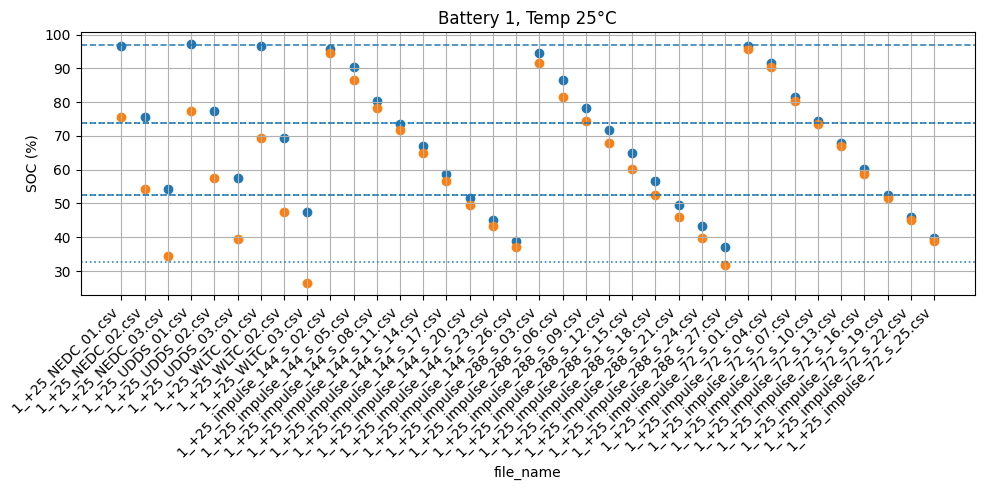

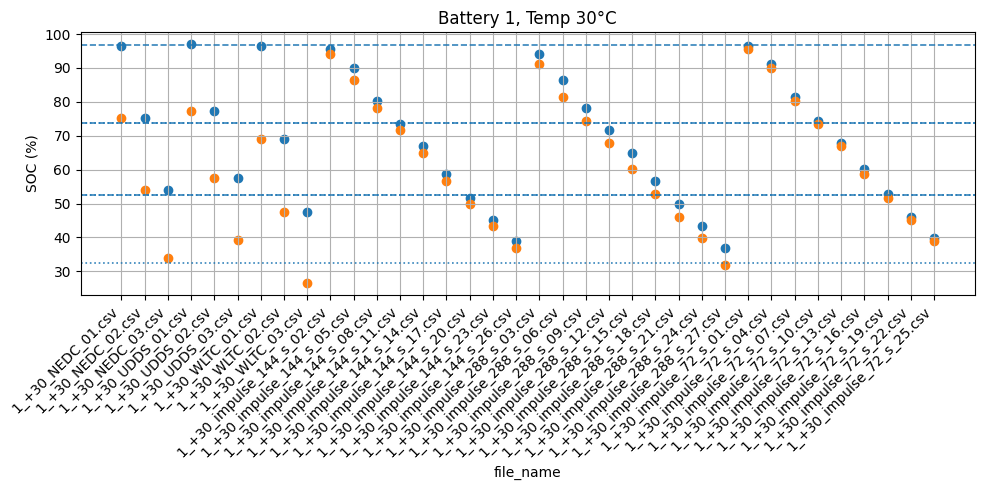

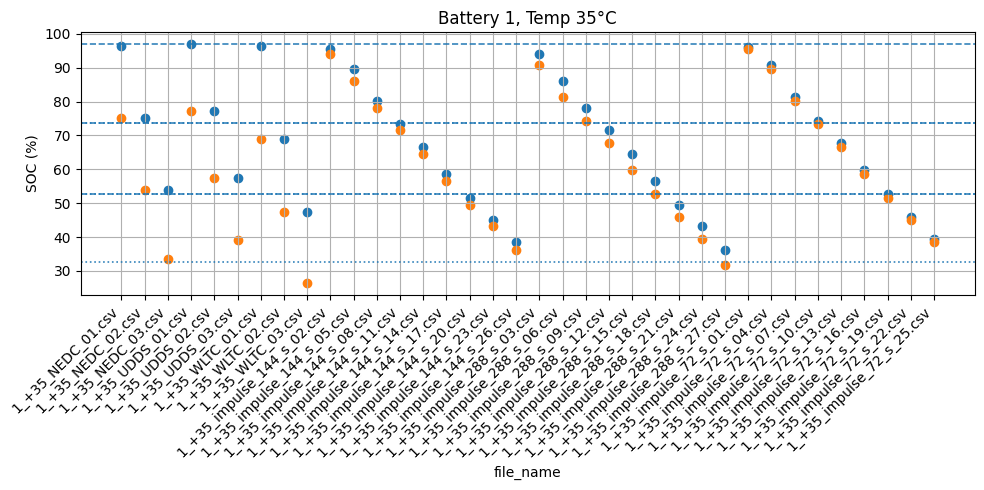

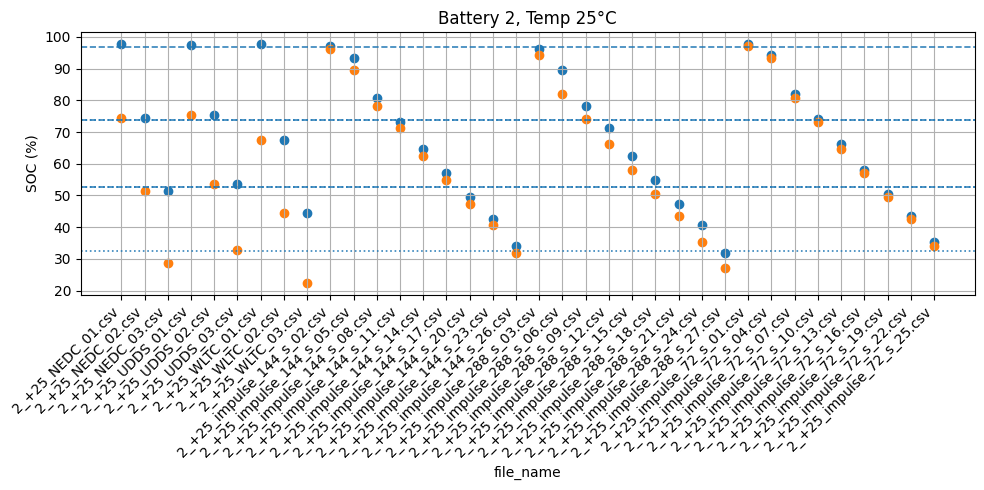

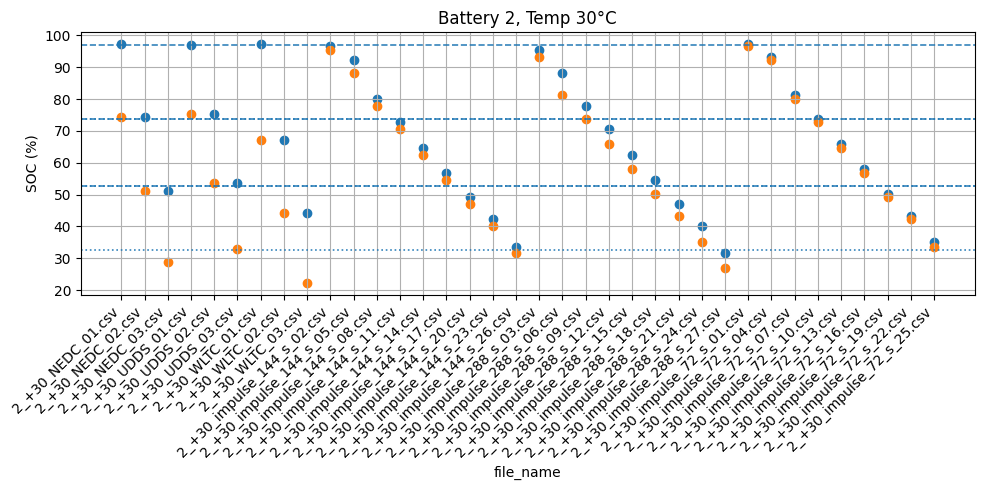

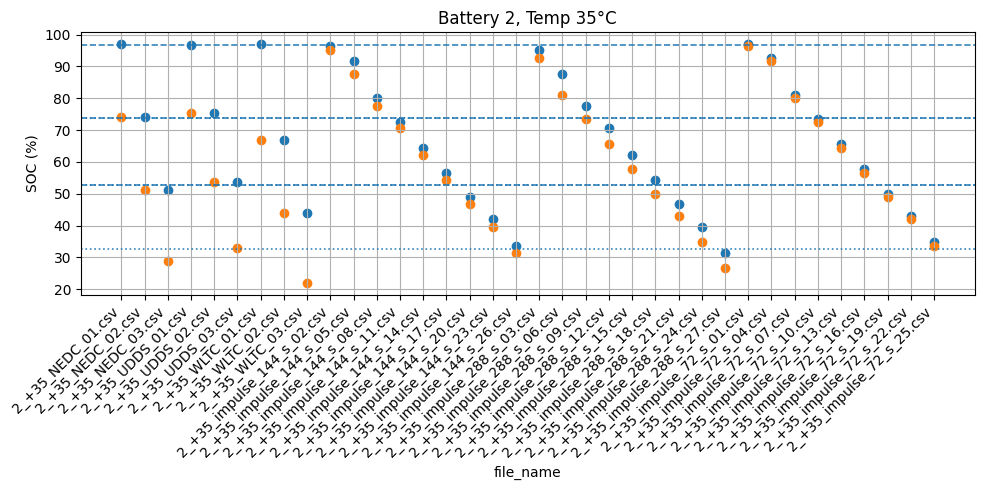

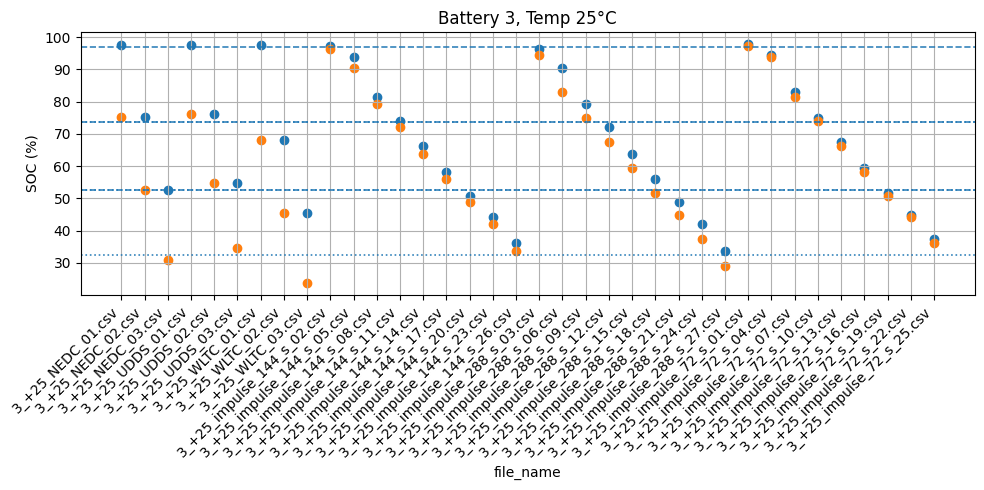

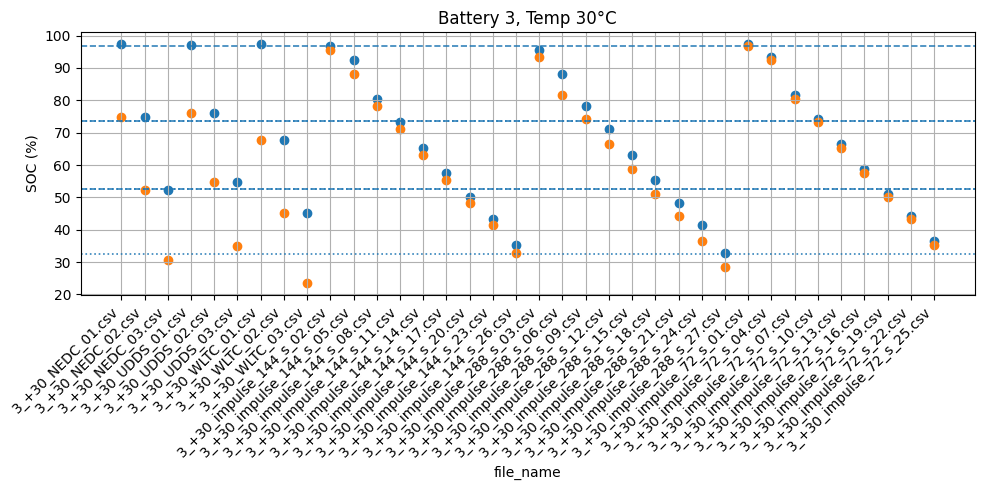

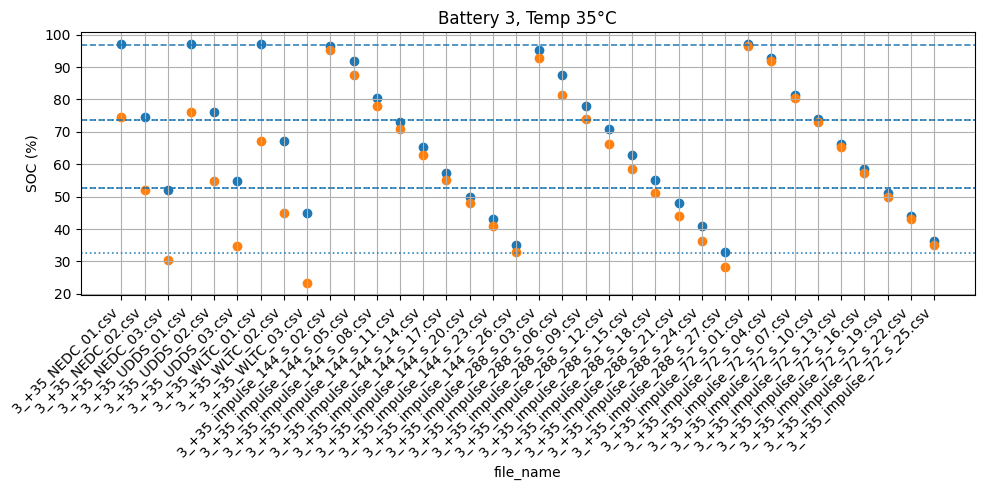

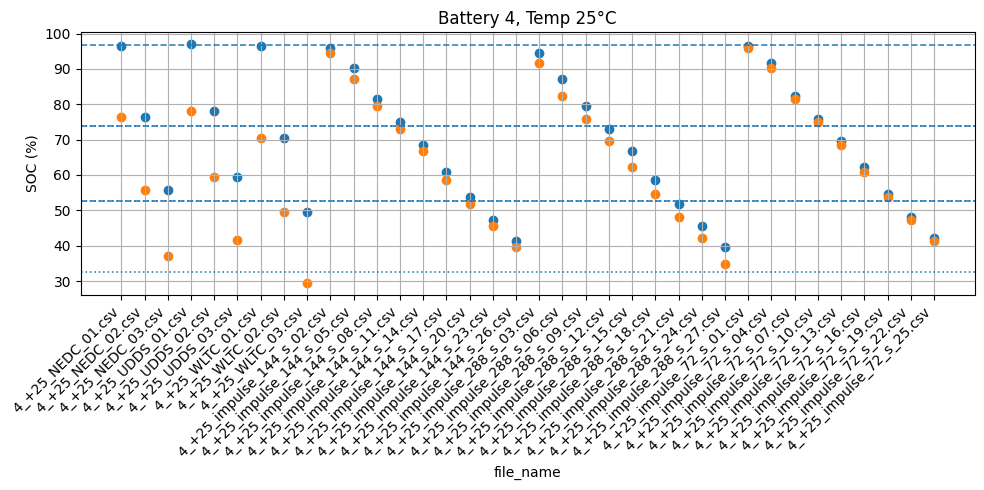

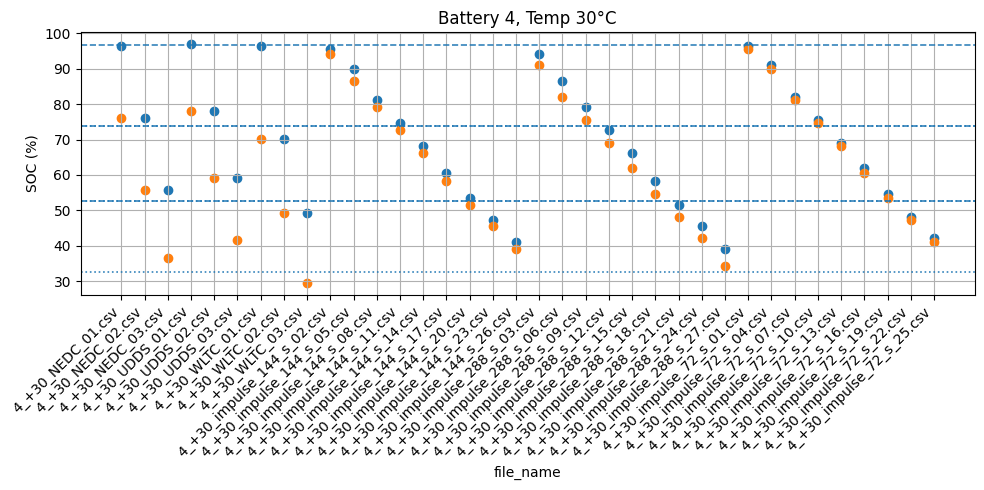

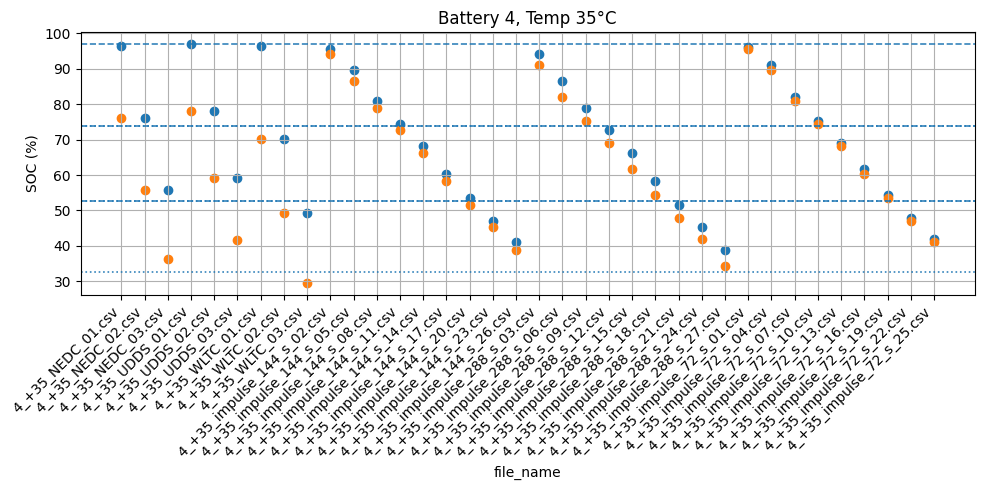

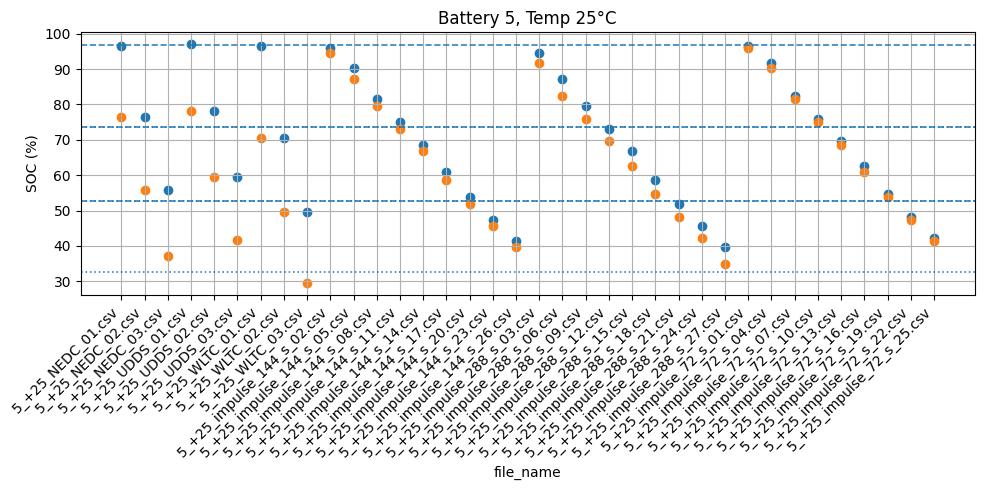

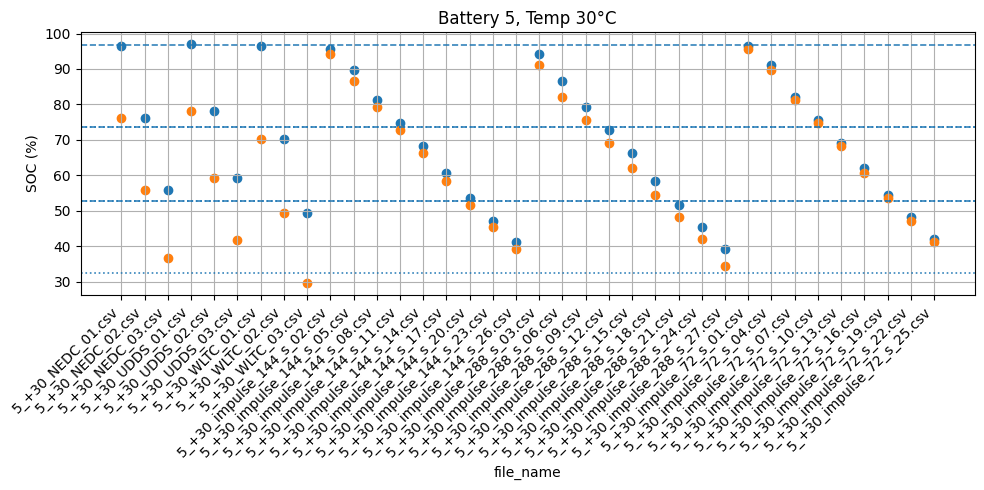

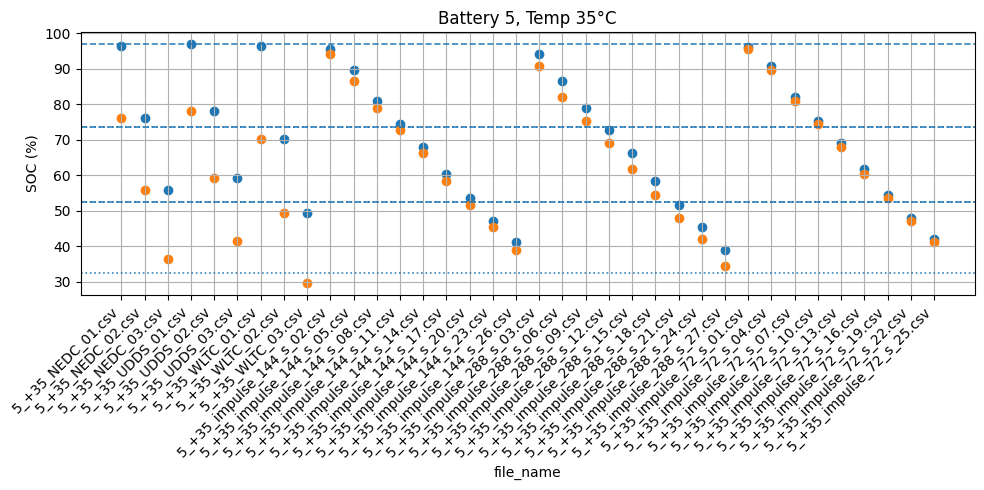

In [6]:
grouped = df.groupby(["bat_num", "temp"])

for (bat_num, temp), group in grouped:
    group = group.sort_values("file_name")

    plt.figure(figsize=(10, 5))

    # scatter — все данные
    plt.scatter(group["file_name"], group["SOC_start"], marker="o", label="SOC_start")
    plt.scatter(group["file_name"], group["SOC_end"], marker="o", label="SOC_end")

    # --- глобальные средние ---
    for suf, vals in global_means.items():
        plt.axhline(
            vals["SOC_start"],
            linestyle="--",
            linewidth=1.2,
            alpha=0.9,
            label=f"GLOBAL mean SOC_start {suf}"
        )
        plt.axhline(
            vals["SOC_end"],
            linestyle=":",
            linewidth=1.2,
            alpha=0.9,
            label=f"GLOBAL mean SOC_end {suf}"
        )

    plt.title(f"Battery {bat_num}, Temp {temp}°C")
    plt.xlabel("file_name")
    plt.ylabel("SOC (%)")
    plt.xticks(rotation=45, ha="right")
    plt.grid(True)
    # легенду можно выключить, если слишком шумно
    # plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

In [7]:
df["SOC_range"] = df.apply(assign_range, axis=1, args=(M02, M03))


In [8]:
df[["profile", "file_name", "SOC_start", "SOC_range"]].head(10)


,profile,file_name,SOC_start,SOC_range
0,impulse_72_s,1_+25_impulse_72_s_01.csv,96.579538,95-75
1,impulse_144_s,1_+25_impulse_144_s_02.csv,95.849146,95-75
2,impulse_288_s,1_+25_impulse_288_s_03.csv,94.516093,95-75
3,impulse_72_s,1_+25_impulse_72_s_04.csv,91.610379,95-75
4,impulse_144_s,1_+25_impulse_144_s_05.csv,90.357663,95-75
5,impulse_288_s,1_+25_impulse_288_s_06.csv,86.572312,95-75
6,impulse_72_s,1_+25_impulse_72_s_07.csv,81.485483,95-75
7,impulse_144_s,1_+25_impulse_144_s_08.csv,80.420789,95-75
8,impulse_288_s,1_+25_impulse_288_s_09.csv,78.350212,95-75
9,impulse_72_s,1_+25_impulse_72_s_10.csv,74.527537,95-75


In [9]:
df[df["profile"].isin(["UDDS", "NEDC", "WLTC"])][
    ["file_name", "SOC_range"]
].drop_duplicates()


,file_name,SOC_range
27,1_+25_UDDS_01.csv,95-75
28,1_+25_UDDS_02.csv,75-55
29,1_+25_UDDS_03.csv,55-35
30,1_+25_NEDC_01.csv,95-75
31,1_+25_NEDC_02.csv,75-55
...,...,...
535,5_+35_NEDC_02.csv,75-55
536,5_+35_NEDC_03.csv,55-35
537,5_+35_WLTC_01.csv,95-75
538,5_+35_WLTC_02.csv,75-55


In [10]:
df["R"] = df["R"].apply(ast.literal_eval)
df["tau"] = df["tau"].apply(ast.literal_eval)

group_cols = ["bat_num", "temp", "profile", "SOC_range"]

agg_df = (
    df
    .groupby(group_cols)
    .agg(
        SOH=("SOH", "mean"),
        Q_Ah=("Q_Ah", "first"),
        eta=("eta", "first"),
        OCV_file_name=("OCV_file_name", "first"),
        R0=("R0", "mean"),
        R=("R", lambda x: np.mean(np.stack(x), axis=0)),
        tau=("tau", lambda x: np.mean(np.stack(x), axis=0)),
    )
    .reset_index()
)

# математическое округление SOH
agg_df["SOH"] = agg_df["SOH"].apply(
    lambda x: int(Decimal(x).quantize(0, rounding=ROUND_HALF_UP))
)

df_result = agg_df.rename(
    columns={
        "temp": "T",
        "SOC_range": "SOC",
        "bat_num": "Battery_ID"
    }
)[
    [
        "profile",
        "Battery_ID",
        "SOH",
        "T",
        "SOC",
        "Q_Ah",
        "eta",
        "OCV_file_name",
        "R0",
        "R",
        "tau",
    ]
]

In [11]:
df_result

,profile,Battery_ID,SOH,T,SOC,Q_Ah,eta,OCV_file_name,R0,R,tau
0,NEDC,1,94,25,55-35,3.289069,0.993163,OCV_1_+25.csv,0.040102,"[0.1850096471970749, -0.15799339382691469]","[74.79622419040015, 74.46096846549297]"
1,NEDC,1,94,25,75-55,3.289069,0.993163,OCV_1_+25.csv,0.043565,"[2.384191218486556, -2.335885648866882]","[76.6982801977665, 75.91917751054542]"
2,NEDC,1,94,25,95-75,3.289069,0.993163,OCV_1_+25.csv,0.044178,"[-3.106252098349827, 3.1380285248812356]","[76.12695193550682, 76.00372428944772]"
3,UDDS,1,94,25,55-35,3.289069,0.993163,OCV_1_+25.csv,0.038852,"[0.05812655725784294, -0.02711379505758365]","[70.43697862158312, 64.55489389765953]"
4,UDDS,1,94,25,75-55,3.289069,0.993163,OCV_1_+25.csv,0.040251,"[0.14614712799051416, -0.09671486794685309]","[70.34196540018883, 63.75848060174332]"
...,...,...,...,...,...,...,...,...,...,...,...
265,impulse_288_s,5,98,35,75-55,3.434987,0.991690,OCV_5_+35.csv,0.041669,"[0.11122546345776486, -0.09116177990283782]","[63.5012423059417, 51.07985799937958]"
266,impulse_288_s,5,98,35,95-75,3.434987,0.991690,OCV_5_+35.csv,0.037150,"[0.04318690585788898, -0.022553434119876353]","[60.16170400151841, 49.73728640608766]"
267,impulse_72_s,5,98,35,55-35,3.434987,0.991690,OCV_5_+35.csv,0.037404,"[0.029591902588795353, -0.01634363843301217]","[23.436367142637035, 5.620305031070973]"
268,impulse_72_s,5,98,35,75-55,3.434987,0.991690,OCV_5_+35.csv,0.038704,"[0.06091549654508518, -0.048651199167644106]","[15.631313769444878, 6.067669779610405]"


In [12]:
df_result.to_csv(current_dir.parent / "validation" / "parameters_for_validation.csv", index=False)